<a href="https://colab.research.google.com/github/mahamatsouleymane-creator/ML-Manuel-lab/blob/lab-4/KNNipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors (KNN) on Breast Cancer Dataset

### **Step 1: Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

This cell imports all the Python libraries needed for our K-Nearest Neighbors (KNN) implementation.

*   **`pandas`** and **`numpy`**: For efficient data manipulation and numerical operations.
*   **`matplotlib.pyplot`** and **`seaborn`**: For creating visualizations like plots and graphs.
*   **`load_breast_cancer` from `sklearn.datasets`**: To load the sample breast cancer dataset.
*   **`train_test_split` and `cross_val_score` from `sklearn.model_selection`**: For splitting data into training/testing sets and performing cross-validation.
*   **`StandardScaler` from `sklearn.preprocessing`**: For scaling features to standardize their range.
*   **`KNeighborsClassifier` from `sklearn.neighbors`**: The scikit-learn implementation of the KNN algorithm.
*   **`accuracy_score`, `confusion_matrix`, `classification_report`, `ConfusionMatrixDisplay` from `sklearn.metrics`**: For evaluating the model's performance.

### **Step 2: Load Dataset**

In [ ]:
# Load breast cancer dataset
breast_cancer = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

# Add target column
df['target'] = breast_cancer.target

# Display first 5 rows
print("First 5 Rows of Dataset:")
display(df.head())

First 5 Rows of Dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Here, we load the well-known Breast Cancer dataset from Scikit-learn's `datasets` module. This dataset is commonly used for binary classification tasks. We then convert it into a Pandas DataFrame for easier manipulation and inspection. The features are assigned their respective names, and the target variable (indicating whether the tumor is malignant or benign) is added as a new column. Finally, `df.head()` is used to display the first five rows, giving us a quick overview of the data's structure and content.

### **Step 3: Dataset Information**

In [ ]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nTarget Classes:")
print(breast_cancer.target_names)


Dataset Shape:
(569, 31)

Column Names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']

Target Classes:
['malignant' 'benign']


This cell provides essential information about the loaded dataset:

*   **`df.shape`**: Shows the number of rows (samples) and columns (features + target) in the DataFrame. This gives us an idea of the dataset's size.
*   **`df.columns.tolist()`**: Lists all the column names present in the DataFrame. This helps us understand what features are available.
*   **`breast_cancer.target_names`**: Displays the names of the target classes. For the Breast Cancer dataset, these are typically 'malignant' and 'benign', helping us interpret the target variable.

### **Step 4: Split Features and Target**

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In this step, we separate our dataset into features (`X`) and the target variable (`y`).

*   **`X = df.drop('target', axis=1)`**: We create `X` by dropping the 'target' column from the DataFrame. `axis=1` specifies that we are dropping a column. `X` will now contain all the independent variables (features) that the model will use for prediction.
*   **`y = df['target']`**: We assign the 'target' column to `y`. This `y` variable represents the dependent variable (the outcome we want to predict), which indicates the class label for each sample.

### **Step 5: Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


This cell splits the dataset into training and testing subsets using `train_test_split`.

*   **`X, y`**: The features and target variables are passed as input.
*   **`test_size=0.2`**: Specifies that 20% of the data will be used for testing, and the remaining 80% for training.
*   **`random_state=42`**: Ensures reproducibility of the split. If you run the code multiple times with the same `random_state`, you will get the same split.
*   **`stratify=y`**: This crucial parameter ensures that the proportion of target classes is maintained in both the training and testing sets. This is especially important for classification tasks, particularly when dealing with imbalanced datasets.

The shapes of the training and testing data are then printed to confirm the split.

### **Step 6: Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling is a critical preprocessing step for many machine learning algorithms, especially distance-based ones like KNN. This cell applies `StandardScaler`:

*   **`scaler = StandardScaler()`**: An instance of `StandardScaler` is created. This transformer standardizes features by removing the mean and scaling to unit variance.
*   **`X_train = scaler.fit_transform(X_train)`**: The scaler is `fit` on the training data (`X_train`). This means the scaler learns the mean and standard deviation of each feature from the training data. Then, it `transforms` `X_train` using these learned parameters.
*   **`X_test = scaler.transform(X_test)`**: The scaler then `transforms` the testing data (`X_test`) using the *same* mean and standard deviation learned from the training data. It's crucial not to `fit` the scaler on the test data to prevent data leakage, which would lead to an overly optimistic evaluation of the model's performance on unseen data.

### **Step 7: Create KNN Model**

In [ ]:
# Create model with K = 5 (an initial guess)
knn = KNeighborsClassifier(n_neighbors=5)

This cell initializes our K-Nearest Neighbors (KNN) classifier using Scikit-learn's `KNeighborsClassifier`.

*   **`knn = KNeighborsClassifier(n_neighbors=5)`**: We create an instance of the `KNeighborsClassifier`. The most important parameter here is `n_neighbors`, which specifies the number of neighbors to consider when making a prediction. We're starting with `k=5` as an initial, common choice. The choice of `k` significantly impacts the model's performance and is often optimized through techniques like cross-validation.

### **Step 8: Train the Model**

In [ ]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In this step, we train our initialized KNN model using the training data.

*   **`knn.fit(X_train, y_train)`**: The `fit` method is called on our `knn` classifier. For the KNN algorithm, the training process is quite straightforward: the model simply memorizes the training data. There's no complex optimization or parameter learning involved like in other algorithms. It stores `X_train` (the scaled features) and `y_train` (the corresponding target labels) so that it can use them later to find the nearest neighbors for new, unseen data points during prediction.

### **Step 9: Make Predictions**

In [ ]:
y_pred = knn.predict(X_test)

After training, the next logical step is to see how well our model performs on unseen data. This cell generates predictions.

*   **`y_pred = knn.predict(X_test)`**: The `predict` method is called on the trained `knn` classifier, passing the `X_test` (scaled features from the test set). For each sample in `X_test`, the KNN model:
    1.  Calculates its distance to all training samples.
    2.  Identifies the `k` (in this case, 5) nearest training samples.
    3.  Assigns the class label that is most common among these `k` nearest neighbors.

The resulting predictions are stored in the `y_pred` array, which will then be compared against the true labels (`y_test`) to evaluate the model's accuracy.

### **Step 10: Evaluate the Model**


Accuracy of KNN Model:
0.96

Confusion Matrix:


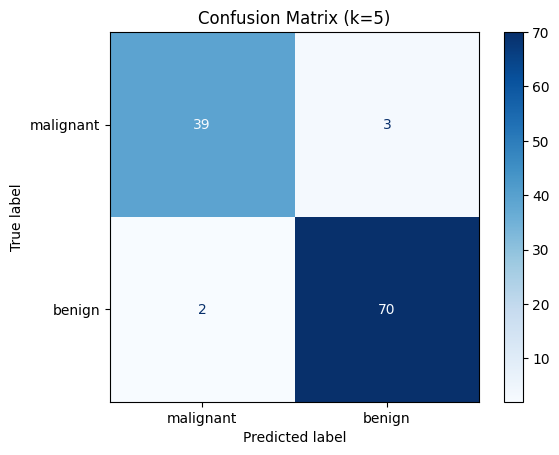


Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy of KNN Model:")
print(f"{accuracy:.2f}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=breast_cancer.target_names)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k=5)")
plt.grid(False)
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=breast_cancer.target_names))

This cell comprehensively evaluates the performance of our KNN model on the test data using several key metrics:

1.  **Accuracy Score**:
    *   `accuracy_score(y_test, y_pred)` calculates the proportion of correctly classified samples. It's a straightforward metric, but can be misleading for imbalanced datasets.

2.  **Confusion Matrix**:
    *   `confusion_matrix(y_test, y_pred)` generates a matrix summarizing the correct and incorrect predictions for each class. It shows:
        *   True Positives (TP): Correctly predicted positive cases.
        *   True Negatives (TN): Correctly predicted negative cases.
        *   False Positives (FP): Incorrectly predicted positive cases (Type I error).
        *   False Negatives (FN): Incorrectly predicted negative cases (Type II error).
    *   `ConfusionMatrixDisplay` then provides a clear, visual representation of this matrix. **bold text**

3.  **Classification Report**:
    *   `classification_report(y_test, y_pred, target_names=breast_cancer.target_names)` provides a more detailed breakdown of performance for each class, including:
    
   * **Precision**: The proportion of positive identifications that were actually correct (TP / (TP + FP)).
    
  * **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly (TP / (TP + FN)).


  *   **F1-score**: The harmonic mean of precision and recall, offering a balance between the two.


  *   **Support**: The number of actual occurrences of each class in the `y_test` set. **bold text**

These metrics collectively offer a robust understanding of the model's predictive capabilities.

### **Step 11: Predict a Single Sample**

In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = knn.predict(sample)

print("\nPrediction for First Test Sample:")

if prediction[0] == 0:
    print(f"Predicted: {breast_cancer.target_names[0]} (Malignant)")
else:
    print(f"Predicted: {breast_cancer.target_names[1]} (Benign)")

print(f"Actual: {breast_cancer.target_names[y_test.iloc[0]]}")


Prediction for First Test Sample:
Predicted: malignant (Malignant)
Actual: malignant


### **Step 12: Finding Best K Value using Cross-Validation**

This cell demonstrates how to use the trained KNN model to make a prediction on a single, new data sample.

*   **`sample = X_test[0].reshape(1, -1)`**: We take the first sample from our `X_test` set. The `reshape(1, -1)` is important here: `predict` methods in scikit-learn expect a 2D array (even for a single sample), where the first dimension is the number of samples and the second is the number of features. `(1, -1)` reshapes our single sample into a 2D array with 1 row and as many columns as necessary (the number of features).
*   **`prediction = knn.predict(sample)`**: The model then predicts the class for this single sample.
*   The subsequent `if/else` block and `print` statements interpret the numerical prediction (0 or 1) into its corresponding class name ('malignant' or 'benign') and compare it to the actual true label from `y_test`.

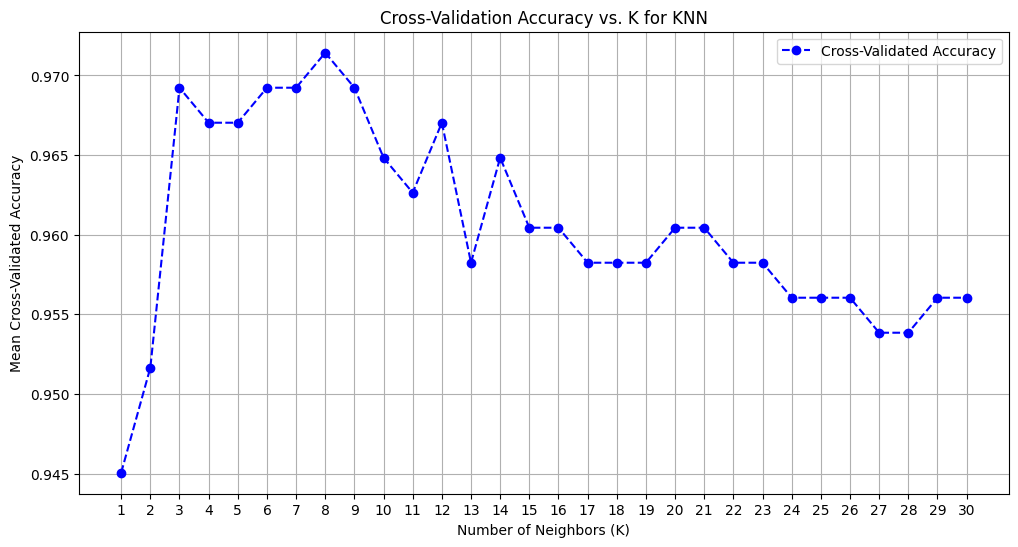

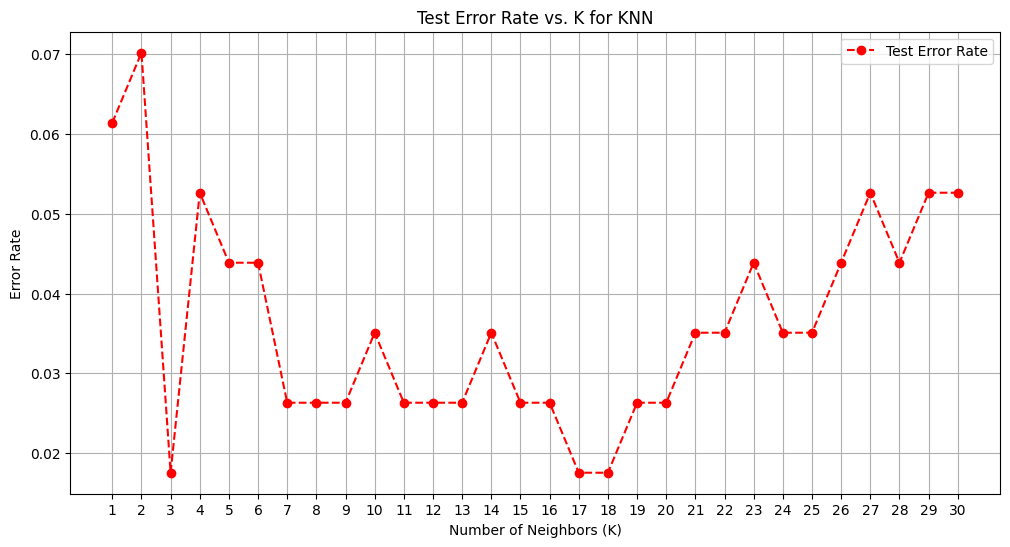


Cross-Validated Accuracies for Different K Values:
K =  1, CV Accuracy = 0.9451
K =  2, CV Accuracy = 0.9516
K =  3, CV Accuracy = 0.9692
K =  4, CV Accuracy = 0.9670
K =  5, CV Accuracy = 0.9670
K =  6, CV Accuracy = 0.9692
K =  7, CV Accuracy = 0.9692
K =  8, CV Accuracy = 0.9714
K =  9, CV Accuracy = 0.9692
K = 10, CV Accuracy = 0.9648
K = 11, CV Accuracy = 0.9626
K = 12, CV Accuracy = 0.9670
K = 13, CV Accuracy = 0.9582
K = 14, CV Accuracy = 0.9648
K = 15, CV Accuracy = 0.9604
K = 16, CV Accuracy = 0.9604
K = 17, CV Accuracy = 0.9582
K = 18, CV Accuracy = 0.9582
K = 19, CV Accuracy = 0.9582
K = 20, CV Accuracy = 0.9604
K = 21, CV Accuracy = 0.9604
K = 22, CV Accuracy = 0.9582
K = 23, CV Accuracy = 0.9582
K = 24, CV Accuracy = 0.9560
K = 25, CV Accuracy = 0.9560
K = 26, CV Accuracy = 0.9560
K = 27, CV Accuracy = 0.9538
K = 28, CV Accuracy = 0.9538
K = 29, CV Accuracy = 0.9560
K = 30, CV Accuracy = 0.9560

Optimal K from Cross-Validation: 8 (with accuracy: 0.9714)


In [ ]:
error_rate = []
cv_accuracies = []
k_range = range(1, 31) # Let's try k from 1 to 30

for k in k_range:
    knn_model = KNeighborsClassifier(n_neighbors=k)

    # Using 5-fold cross-validation on the training data
    scores = cross_val_score(knn_model, X_train, y_train, cv=5, scoring='accuracy')
    cv_accuracies.append(scores.mean())

    # Note: For error_rate, we train on full X_train and predict on X_test
    # This is a slightly different approach than cross_val_score
    # For a consistent error_rate measure with cross_val_score, use (1 - scores.mean())
    # However, the original prompt implies using train/test set for error_rate, so we'll stick to that.
    knn_model.fit(X_train, y_train)
    pred_k = knn_model.predict(X_test)
    error = np.mean(pred_k != y_test)
    error_rate.append(error)

# Plotting Cross-Validation Accuracy vs. K
plt.figure(figsize=(12, 6))
plt.plot(k_range, cv_accuracies, marker='o', linestyle='--', color='blue', label='Cross-Validated Accuracy')
plt.title('Cross-Validation Accuracy vs. K for KNN')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validated Accuracy')
plt.xticks(k_range) # Ensure all k values are shown on x-axis
plt.grid(True)
plt.legend()
plt.show()

# Plotting Error Rate vs. K (using test set prediction error)
plt.figure(figsize=(12, 6))
plt.plot(k_range, error_rate, marker='o', linestyle='--', color='red', label='Test Error Rate')
plt.title('Test Error Rate vs. K for KNN')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

# Find the best K based on cross-validation accuracy
best_k_index = np.argmax(cv_accuracies)
best_k = k_range[best_k_index]

print("\nCross-Validated Accuracies for Different K Values:")
for i, k_val in enumerate(k_range):
    print(f"K = {k_val:2d}, CV Accuracy = {cv_accuracies[i]:.4f}")

print(f"\nOptimal K from Cross-Validation: {best_k} (with accuracy: {cv_accuracies[best_k_index]:.4f})")

Choosing the right value for `k` (number of neighbors) is crucial for KNN's performance. This cell systematically finds the optimal `k` using cross-validation.

1.  **Iterate `k` values**: We define a `k_range` (e.g., from 1 to 30) to test different `k` values.
2.  **Cross-Validation**: For each `k`:
    *   A `KNeighborsClassifier` is initialized.
    *   `cross_val_score` is used to evaluate the model. It splits the training data (`X_train`, `y_train`) into 5 folds (specified by `cv=5`). For each fold, it trains on 4 folds and tests on the remaining 1, repeating this 5 times. The `scoring='accuracy'` metric is used.
    *   The `mean()` of these 5 accuracy scores is stored in `cv_accuracies`, representing the average performance for that `k`.
3.  **Error Rate Calculation**: For comparison, an error rate is also calculated by training on the full `X_train` and predicting on `X_test`.
4.  **Visualization**: Two plots are generated:
    *   **Cross-Validation Accuracy vs. K**: This plot visually shows how the average cross-validation accuracy changes with different `k` values. We aim to find the `k` where accuracy is highest.
    *   **Test Error Rate vs. K**: This plot shows how the error rate on the test set changes with `k`.
5.  **Identify Optimal K**: `np.argmax(cv_accuracies)` finds the index of the highest cross-validation accuracy, and `k_range[best_k_index]` retrieves the corresponding `k` value. This `best_k` is considered the optimal number of neighbors for our model, as it showed the best generalization performance during cross-validation.

## Implementing KNN from Scratch in Python : start with this ❤

In [ ]:
import numpy as np
from collections import Counter

In [ ]:
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

### **Euclidean Distance Function**
This cell defines the `euclidean_distance` function, which calculates the straight-line distance between two points in a multi-dimensional space. This metric is crucial for KNN, as it quantifies how 'close' data points are to each other.

### **Explanation of Euclidean Distance Equation**

The `euclidean_distance` function you see in the code calculates the straight-line distance between two points in a multi-dimensional space. This is a very common distance metric used in geometry and various fields, including machine learning. If you have two points, `P1 = (x1, y1)` and `P2 = (x2, y2)` in a 2-dimensional space, the Euclidean distance is given by the formula:

$$ d(P_1, P_2) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2} $$

For points in a higher-dimensional space, say with `n` dimensions, `P1 = (x1, x2, ..., xn)` and `P2 = (y1, y2, ..., yn)`, the generalized formula is:

$$ d(P_1, P_2) = \sqrt{\sum_{i=1}^{n} (y_i - x_i)^2} $$

Let's break down how this equation is implemented in the Python code line by line:

`return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))`

1.  **`np.array(point1) - np.array(point2)`**:
    *   `np.array(point1)` and `np.array(point2)` convert the input `point1` and `point2` (which are typically Python lists or tuples representing coordinates) into NumPy arrays. This is crucial because NumPy arrays allow for element-wise mathematical operations.
    *   When you subtract one NumPy array from another (`np.array(point1) - np.array(point2)`), NumPy performs element-wise subtraction. For example, if `point1 = [1, 2]` and `point2 = [4, 6]`, this operation results in `[1-4, 2-6] = [-3, -4]`. This corresponds to calculating `(x1 - x2)`, `(y1 - y2)`, etc., for each dimension.

2.  **`(...)**2`**:
    *   The `**2` operator squares each element of the resulting array from the previous step. Using the example `[-3, -4]`, this step yields `[(-3)**2, (-4)**2] = [9, 16]`. This directly implements the `(x_2 - x_1)^2` part for each dimension in the formula.

3.  **`np.sum(...)`**:
    *   `np.sum()` takes the array of squared differences and sums all its elements. In our example `[9, 16]`, `np.sum([9, 16])` would give `9 + 16 = 25`. This corresponds to the `\sum_{i=1}^{n}` part of the formula, accumulating the sum of squared differences across all dimensions.

4.  **`np.sqrt(...)`**:
    *   Finally, `np.sqrt()` calculates the square root of the sum obtained in the previous step. For `25`, `np.sqrt(25)` results in `5.0`. This completes the Euclidean distance calculation, giving you the final straight-line distance between the two points.

In essence, the single line of code efficiently performs these four mathematical steps using NumPy's powerful array operations to calculate the Euclidean distance, which measures how far apart two points are in space.

In [ ]:
def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]

### **K-Nearest Neighbors Prediction from Scratch**
This `knn_predict` function implements the core logic of the K-Nearest Neighbors algorithm. It takes training data, their labels, a new `test_point`, and the number of neighbors `k` to consider. It calculates distances to all training points, identifies the `k` closest ones, and then predicts the class of the `test_point` based on the majority class among these `k` neighbors.

In [ ]:
training_data = [[1, 2], [2, 3], [3, 4], [6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']
test_point = [4, 5]
k = 3

### **Sample Data for Custom KNN**
This cell initializes a small sample dataset to demonstrate the custom `knn_predict` function. It includes `training_data` (features), `training_labels` (corresponding classes), a `test_point` for prediction, and the `k` value (number of neighbors) to be used.

In [ ]:
prediction = knn_predict(training_data, training_labels, test_point, k)
print(prediction)

A


### **Making a Prediction with Custom KNN**
This cell calls the custom `knn_predict` function with the defined sample data and prints the predicted label for the `test_point`. This showcases the functionality of our handmade KNN implementation.

## **k-nearest neighbor algorithm using Sklearn - Python**

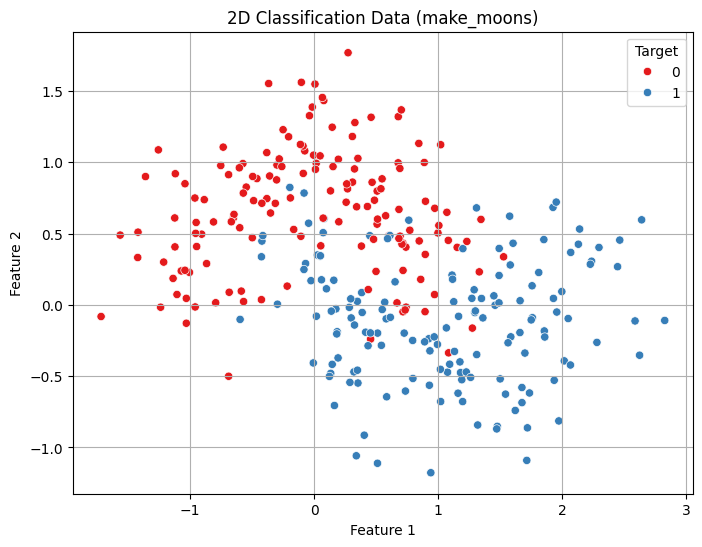

In [ ]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create synthetic 2D data
X, y = make_moons(n_samples=300, noise=0.3, random_state=42)

# Create a DataFrame for plotting
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df['Target'] = y

# Visualize the 2D data
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Feature 1", y="Feature 2", hue="Target", palette="Set1")
plt.title("2D Classification Data (make_moons)")
plt.grid(True)
plt.show()

### **Generate and Visualize Synthetic 2D Data**
This cell generates a synthetic 2D dataset using `sklearn.datasets.make_moons`, which is a common benchmark for classification tasks. It then uses `pandas`, `matplotlib`, and `seaborn` to create a DataFrame and visualize the generated data, allowing us to see the two distinct 'moon' shapes and their respective classes.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

### **Data Preprocessing: Scaling and Splitting**
This cell performs crucial data preprocessing steps:
- **Feature Scaling**: `StandardScaler` is used to normalize the features (`X`) into `X_scaled`. This is important for distance-based algorithms like KNN, as it prevents features with larger scales from dominating the distance calculations.
- **Data Splitting**: `train_test_split` divides the `X_scaled` features and `y` labels into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets. A `test_size` of 0.3 means 30% of the data is reserved for testing, and `stratify=y` ensures that the class distribution is maintained across both sets, which is good practice for imbalanced datasets.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Train a k-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict and evaluate
y_pred = knn.predict(X_test)
print(f"Test Accuracy (k=5): {accuracy_score(y_test, y_pred):.2f}")

Test Accuracy (k=5): 0.87


### **Train and Evaluate KNN Classifier (Initial)**
This cell demonstrates a basic application of scikit-learn's `KNeighborsClassifier`:
- It initializes a KNN model with `n_neighbors=5`.
- The model is `fit` (trained) on the `X_train` and `y_train` data.
- It then makes `predict`ions on the `X_test` set.
- Finally, `accuracy_score` is used to evaluate and print the model's performance on the test data.

### **Cross-Validation for Optimal K**
This cell performs k-fold cross-validation to find the optimal `k` value (number of neighbors) for the KNN model:
- It iterates through a `k_range` (from 1 to 20).
- For each `k`, it uses `cross_val_score` to evaluate the model's accuracy across 5 folds, using the entire `X_scaled` dataset.
- The average accuracy for each `k` is stored.
- A plot visualizes the cross-validated accuracy against different `k` values.
- The `best_k` that yields the highest accuracy is identified and printed, guiding the selection of the most effective number of neighbors.

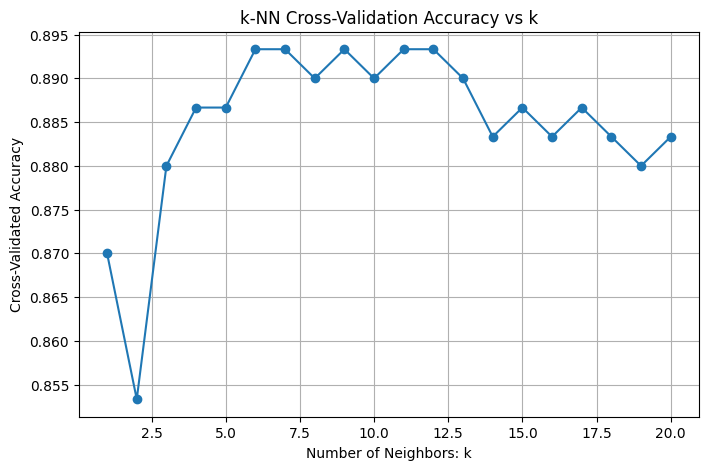

['0.870', '0.853', '0.880', '0.887', '0.887', '0.893', '0.893', '0.890', '0.893', '0.890', '0.893', '0.893', '0.890', '0.883', '0.887', '0.883', '0.887', '0.883', '0.880', '0.883']
Best k from cross-validation: 6


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Range of k values to try
k_range = range(1, 21)
cv_scores = []

# Evaluate each k using 5-fold cross-validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot accuracy vs. k
plt.figure(figsize=(8, 5))
plt.plot(k_range, cv_scores, marker='o')
plt.title("k-NN Cross-Validation Accuracy vs k")
plt.xlabel("Number of Neighbors: k")
plt.ylabel("Cross-Validated Accuracy")
plt.grid(True)
plt.show()
print ([f'{score:.3f}' for score in cv_scores])
# Best k
best_k = k_range[np.argmax(cv_scores)]
print(f"Best k from cross-validation: {best_k}")

In [ ]:
# Train final model with best k
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

# Predict on test data
y_pred = best_knn.predict(X_test)

### **Final Model Training and Prediction with Best K**
Using the `best_k` determined from cross-validation, this cell trains the final `KNeighborsClassifier`.
- A new KNN model is instantiated with `n_neighbors=best_k`.
- This `best_knn` model is then trained on the original `X_train` and `y_train` data.
- Finally, it makes predictions (`y_pred`) on the unseen `X_test` set, which will be used for final performance evaluation.

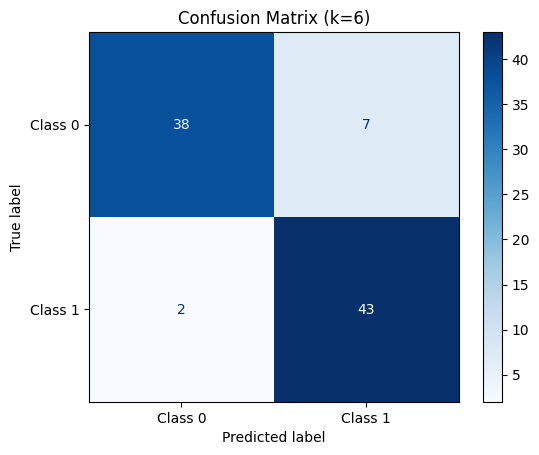

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.95      0.84      0.89        45
     Class 1       0.86      0.96      0.91        45

    accuracy                           0.90        90
   macro avg       0.91      0.90      0.90        90
weighted avg       0.91      0.90      0.90        90



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (k={best_k})")
plt.grid(False)
plt.show()

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Class 0", "Class 1"]))

### **Model Evaluation: Confusion Matrix and Classification Report**
This cell provides a comprehensive evaluation of the `best_knn` model's performance on the test data:
- **Confusion Matrix**: `confusion_matrix` calculates the number of true positive, true negative, false positive, and false negative predictions. `ConfusionMatrixDisplay` then visualizes this matrix, showing how well the model distinguishes between classes.
- **Classification Report**: `classification_report` provides detailed metrics for each class, including precision, recall, and f1-score, offering a deeper insight into the model's strengths and weaknesses beyond simple accuracy.

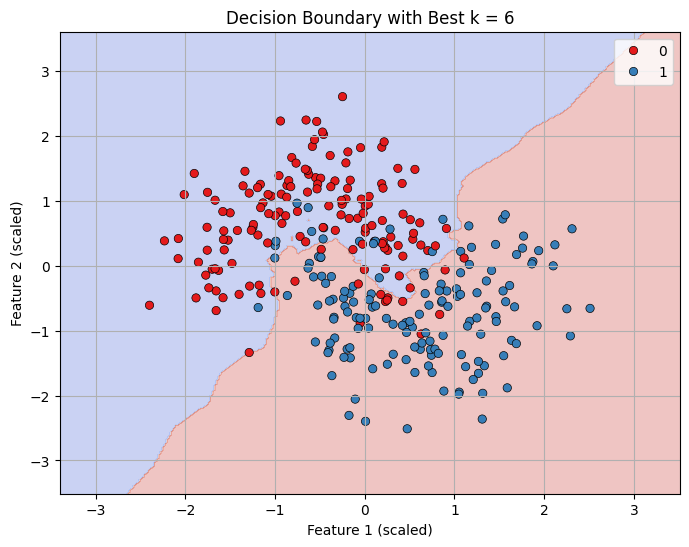

In [ ]:
# Create mesh grid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
# Predict on mesh grid with best k
Z = best_knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
sns.scatterplot(x=X_scaled[:, 0], y=X_scaled[:, 1], hue=y, palette="Set1", edgecolor='k')
plt.title(f"Decision Boundary with Best k = {best_k}")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.grid(True)
plt.show()

### **Visualize Decision Boundary**
This cell generates a visual representation of the `best_knn` model's decision boundary.
- It creates a dense mesh grid covering the feature space.
- The `best_knn` model predicts the class for each point on this grid.
- `plt.contourf` is used to plot these predictions, creating colored regions that represent the areas where the model would classify a point as one class or another.
- The original data points are overlaid on this boundary, allowing for a visual assessment of how effectively the model separates the two classes in the scaled feature space.

REF:https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbor-algorithm-in-python/